# The Normal Distribution
The Normal distribution, also known as the Gaussian distribution, is one of the most important distributions in statistics and data science. 

It is characterized by its bell-shaped curve and is defined by its mean $\mu$ and standard deviation $\sigma$. In this lesson, we will explore the properties of the Normal distribution, how to calculate probabilities, and the concept of maximum likelihood estimation.


## Group Discussion Question
Why is the Normal distribution so widely used in statistics and data science? 

What are some real-world examples where the Normal distribution is applicable? 

Discuss with your group and provide examples of how understanding the Normal distribution can be beneficial.


## Properties of the Normal Distribution
The probability density function (PDF) of the Normal distribution is given by:

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

### Plotting the Normal Distribution

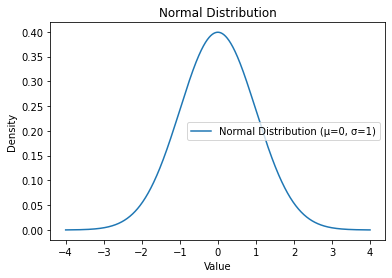

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 0  # Mean
sigma = 1  # Standard deviation

# Generate data
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Plot the distribution
plt.plot(x, y, label='Normal Distribution (μ=0, σ=1)')
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Calculating Probabilities
The cumulative distribution function (CDF) of the Normal distribution gives the probability that a random variable \( X \) is less than or equal to a certain value \( x \):

$$
P(X \leq x) = \int_{-\infty}^{x} f(t) \, dt
$$

### Example: Probability Calculation
Calculate the probability that a randomly chosen value from a standard Normal distribution is less than 1. 

In [3]:
# Calculate probability
prob = norm.cdf(1, mu, sigma)
print(f'P(X ≤ 1) for N(0, 1): {prob:.4f}')

P(X ≤ 1) for N(0, 1): 0.8413


### Q: What is the Empirical Rule?

(Hint: look up an image and discuss the implications of variance and probabilities)

### Probability of a Single Outcome
The probability of a single outcome in a continuous distribution like the Normal distribution is zero. 

This is because the area under the curve at a single point is infinitesimally small.

### Example: Density of X = 0
This is NOT the probability, but rather the density of probability around a specific point. Literally, it is a point on the Normal distribution.


In [4]:
# Probability of a single outcome
prob_single = norm.pdf(0, mu, sigma)
print(f'P(X = 0) for N(0, 1): {prob_single:.4f}')

P(X = 0) for N(0, 1): 0.3989


## Maximum Likelihood Estimation
Maximum Likelihood Estimation (MLE) is a method for estimating the parameters of a statistical model. 

The goal is to find the parameter values that maximize the likelihood of observing the already recorded data.

For a Normal distribution, the likelihood function is given by:

$$
L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x_i-\mu)^2}{2\sigma^2}}
$$

### Example: MLE for Normal Distribution
Given a dataset, find the mean $\mu$ that maximizes the likelihood of observing the data.

MLE for μ: 4.7923, σ: 1.8072


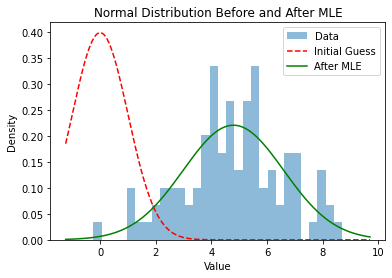

In [8]:
from scipy.optimize import minimize

# Generate sample data from a Normal distribution
np.random.seed(42)
data = np.random.normal(5, 2, size=100)

# Define the negative log-likelihood function
def neg_log_likelihood(params, data):
    mu = params[0]
    sigma = params[1]
    n = len(data)
    return 0.5 * n * np.log(2 * np.pi * sigma**2) + 0.5 * np.sum((data - mu)**2 / sigma**2)

# Initial parameter guesses
initial_params = [0, 1]

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=[(-10, 10), (0.1, 10)])
mu_mle, sigma_mle = result.x

print(f'MLE for μ: {mu_mle:.4f}, σ: {sigma_mle:.4f}')

# Plot before and after MLE
x = np.linspace(min(data) - 1, max(data) + 1, 1000)
y_initial = norm.pdf(x, initial_params[0], initial_params[1])
y_mle = norm.pdf(x, mu_mle, sigma_mle)

plt.hist(data, bins=30, density=True, alpha=0.5, label='Data')
plt.plot(x, y_initial, 'r--', label='Initial Guess')
plt.plot(x, y_mle, 'g-', label='After MLE')
plt.title('Normal Distribution Before and After MLE')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Practice Problems
1. Generate a dataset from a Normal distribution with a mean of 10 and a standard deviation of 3. Plot the distribution and calculate the probability that a randomly chosen value is less than 12.

2. Explain why the probability of a single outcome in a continuous distribution is zero. Provide a detailed explanation with reference to the Normal distribution.

3. Use the Maximum Likelihood Estimation method to estimate the mean and standard deviation of a given dataset. Compare the estimated parameters with the true parameters used to generate the dataset.

4. Discuss the significance of the Normal distribution in Central Limit Theorem. How does it justify the use of the Normal distribution in various statistical analyses?


# Conclusion
The Normal distribution is a fundamental concept in statistics and data science, widely used due to its properties and the Central Limit Theorem. 

Understanding how to calculate probabilities, the concept of maximum likelihood estimation, and the implications of the distribution are crucial for effective data analysis and modeling.
